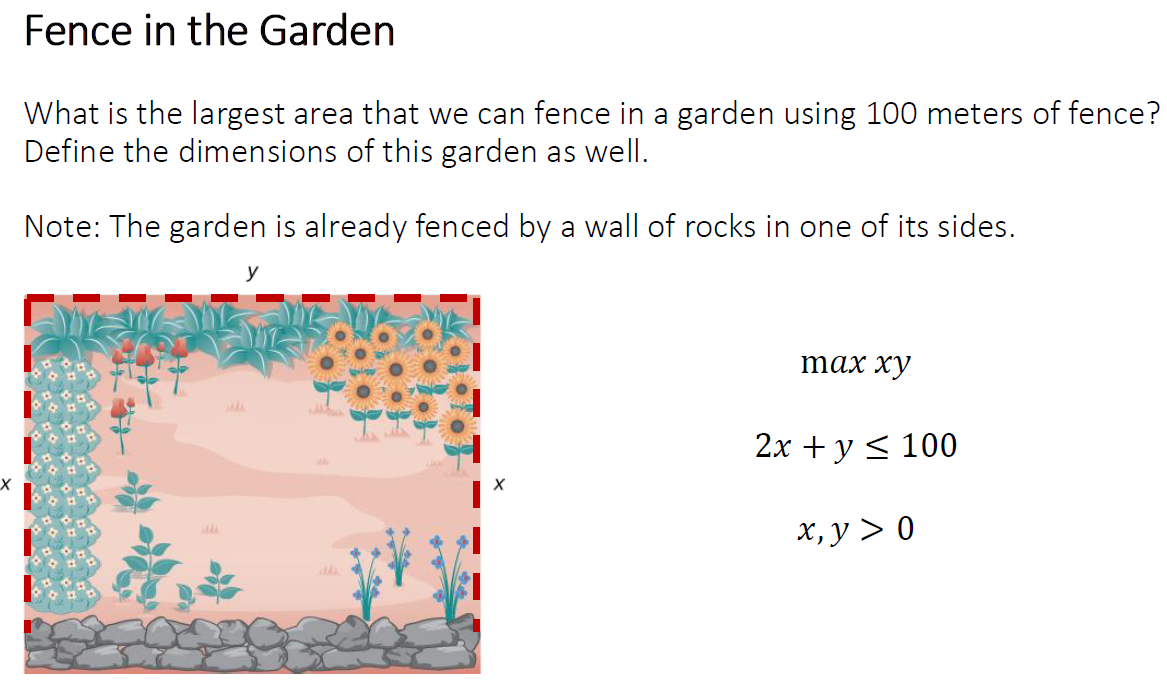

In [1]:
import pyomo.environ as pyo, numpy as np
from pyomo.environ import *
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

model.x = pyo.Var(bounds=(0,None))
model.y = pyo.Var(bounds=(0,None))
x = model.x
y = model.y

model.obj = pyo.Objective(expr= x*y, sense=maximize)
model.c1 = pyo.Constraint(expr= 2*x+y <= 100)

opt = SolverFactory('ipopt', executable=r"solvers\ipopt.exe")
opt.solve(model)

print('x:', np.round(pyo.value(x),2))
print('y:', np.round(pyo.value(y),2))
print('A:', np.round(pyo.value(x)*pyo.value(y),2))

x: 25.0
y: 50.0
A: 1250.0


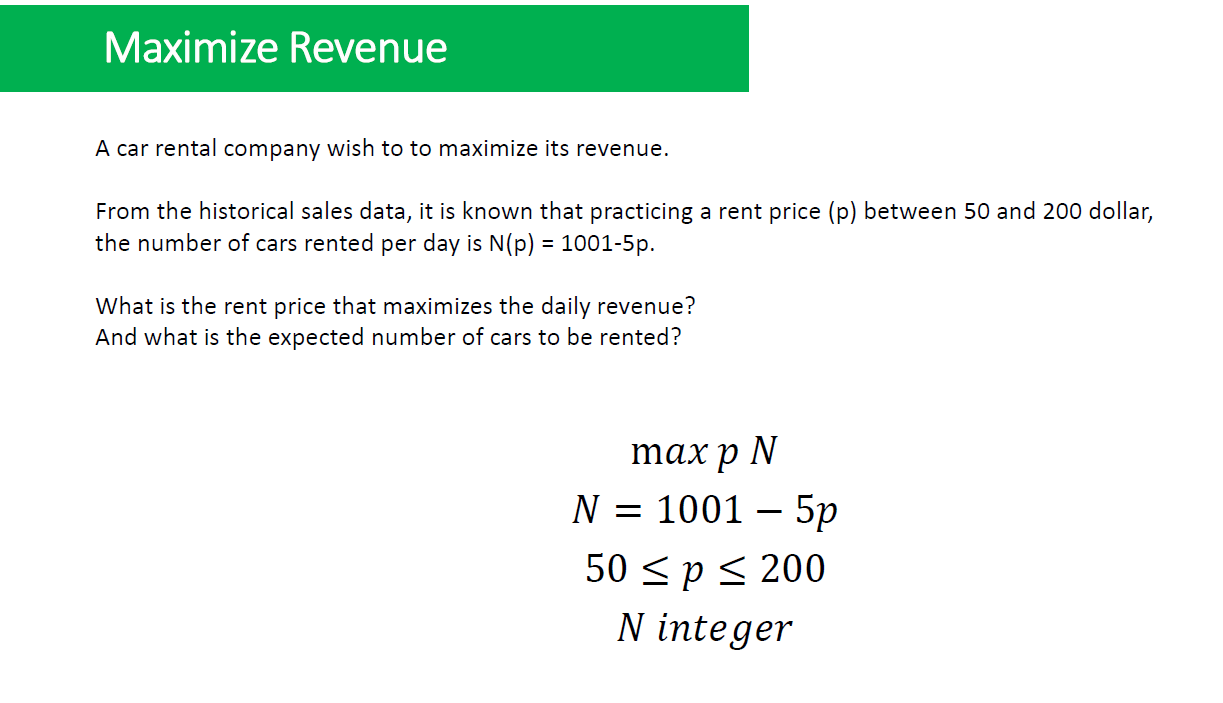

In [2]:
import pyomo.environ as pyo, numpy as np
from pyomo.environ import *
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

model.p = pyo.Var(bounds=(50,200))
model.N = pyo.Var(within=Integers, bounds=(0,None))
p = model.p
N = model.N

model.obj = pyo.Objective(expr= p*N, sense=maximize)
model.C1 = pyo.Constraint(expr= N == 1001-5*p)

opt = SolverFactory('couenne', executable=r"solvers\couenne.exe")
opt.solve(model)

print('p:', np.round(pyo.value(p),2))
print('N:', np.round(pyo.value(N),2))
print('receita:(收入)', pyo.value(p)*pyo.value(N))

p: 100.0
N: 501.0
receita:(收入) 50100.0


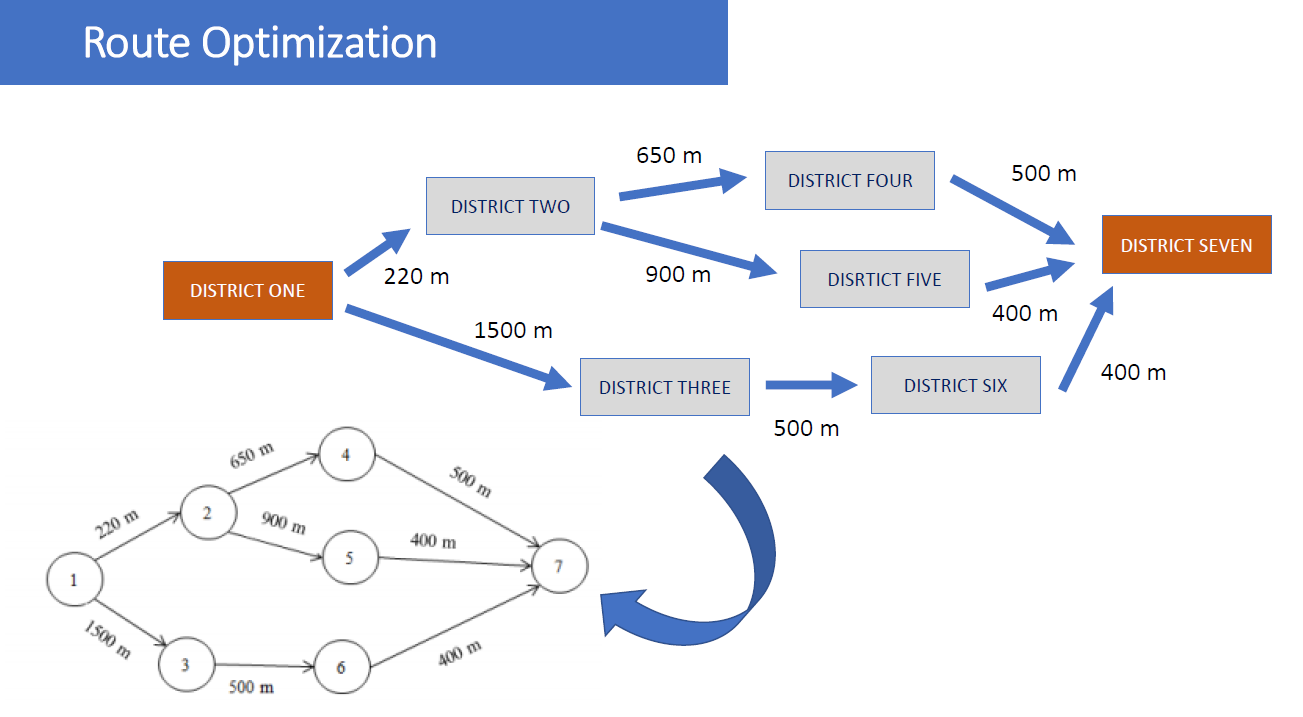

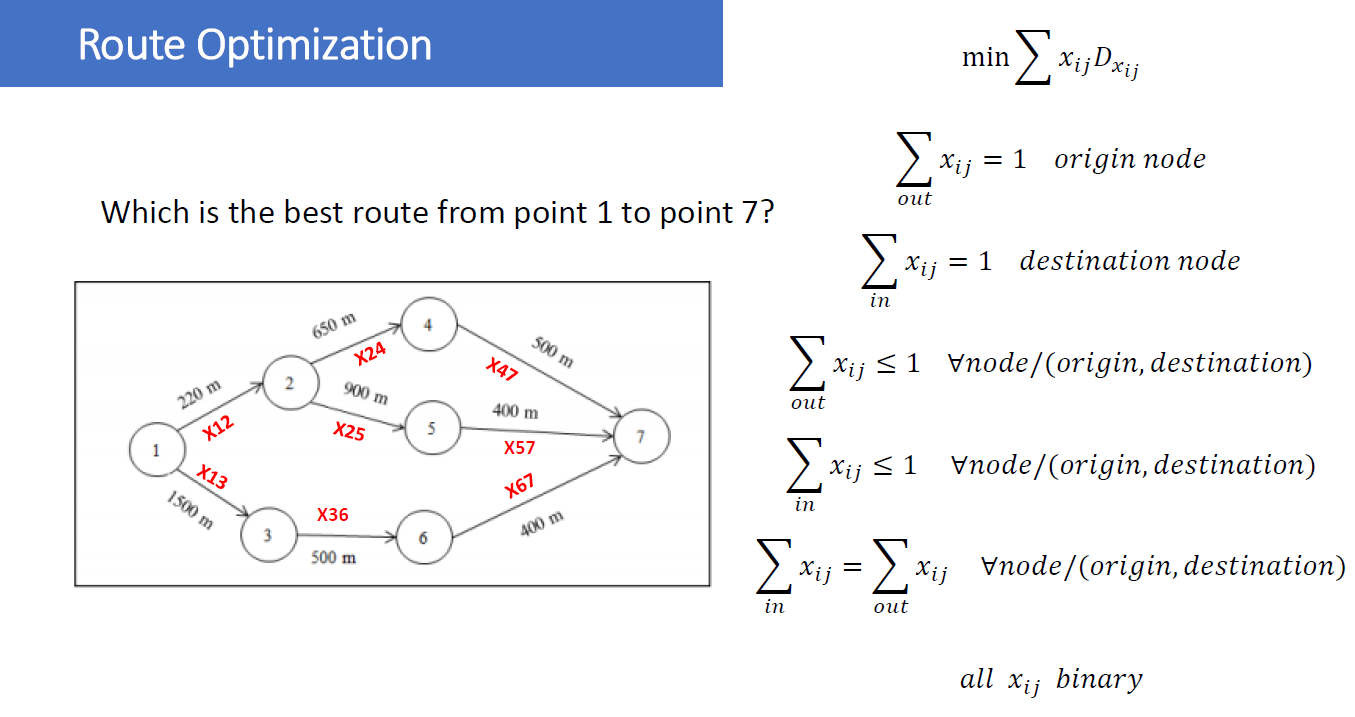

In [3]:
import pandas as pd, numpy as np
from ortools.sat.python import cp_model

#inputs
nodes = pd.read_excel('route_inputs.xlsx', sheet_name='nodes')
paths = pd.read_excel('route_inputs.xlsx', sheet_name='paths')
n_nodes = len(nodes)
n_paths = len(paths)

#model
model = cp_model.CpModel()
x = np.zeros(n_paths).tolist()
for p in paths.index:
    x[p] = model.NewIntVar(0,1,'x[{}]'.format([p]))

#objective function
objFun = sum([x[p] * paths.distance[p] for p in paths.index])
model.Minimize(objFun)

#constraint sum(x) == 1 (origin and destination)
node_origin = int(nodes.loc[nodes.description == 'origin', 'node'].iloc[0])
node_destination = int(nodes.loc[nodes.description == 'destination', 'node'].iloc[0])
model.Add(sum([x[p] for p in paths.index[paths.node_from==node_origin]]) == 1)
model.Add(sum([x[p] for p in paths.index[paths.node_to==node_destination]]) == 1)

#constraint sum(x, in) == sum(x, out)
for node in nodes.loc[nodes.description == 'middle point', 'node']:
    sum_in = sum([x[p] for p in paths.index[paths.node_to==node]])
    sum_out = sum([x[p] for p in paths.index[paths.node_from==node]])
    model.Add(sum_in == sum_out)
    
#solve
solver = cp_model.CpSolver()
status = solver.Solve(model)

#print
print('status =', solver.StatusName(status))
print('OF =', solver.ObjectiveValue())

paths['activated'] = 0
for p in paths.index:
    paths.activated[p] = solver.Value(x[p])
print(paths)

status = OPTIMAL
OF = 1370.0
   node_from  node_to  distance  activated
0          1        2       220          1
1          1        3      1500          0
2          2        4       650          1
3          2        5       900          0
4          4        7       500          1
5          5        7       400          0
6          3        6       500          0
7          6        7       400          0
